# scRNA-seq Analysis of Human PBMCs
Author: ATHIRA  |  Date: April 2026  |  Tools: Python, Scanpy
End-to-end single-cell RNA sequencing analysis of 2,700 peripheral blood mononuclear cells (PBMCs) from a healthy donor. Pipeline covers quality control, normalization, dimensionality reduction, clustering, and cell type annotation — identifying 10 distinct immune cell populations.

In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
adata = sc.datasets.pbmc3k()

print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)
print("Setup complete!")

Cells: 2700
Genes: 32738
Setup complete!


In [2]:
import scanpy as sc
adata = sc.datasets.pbmc3k()

In [3]:
adata = sc.datasets.pbmc3k()
print(adata)
print("\nFirst 5 cell names:", adata.obs_names[:5].tolist())
print("First 5 gene names:", adata.var_names[:5].tolist())

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

First 5 cell names: ['AAACATACAACCAC-1', 'AAACATTGAGCTAC-1', 'AAACATTGATCAGC-1', 'AAACCGTGCTTCCG-1', 'AAACCGTGTATGCG-1']
First 5 gene names: ['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8']


## Phase 2 — Quality Control
We filter low-quality cells using three metrics: number of genes detected per cell, total RNA counts, and percentage of mitochondrial gene expression. Cells with high mitochondrial percentage (>20%) are likely damaged or dying and are removed. We also remove genes detected in fewer than 3 cells to reduce noise.
Thresholds applied: min_genes=200 · pct_counts_mt < 20 · min_cells=3

In [4]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
print(adata.obs.columns.tolist())

['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']


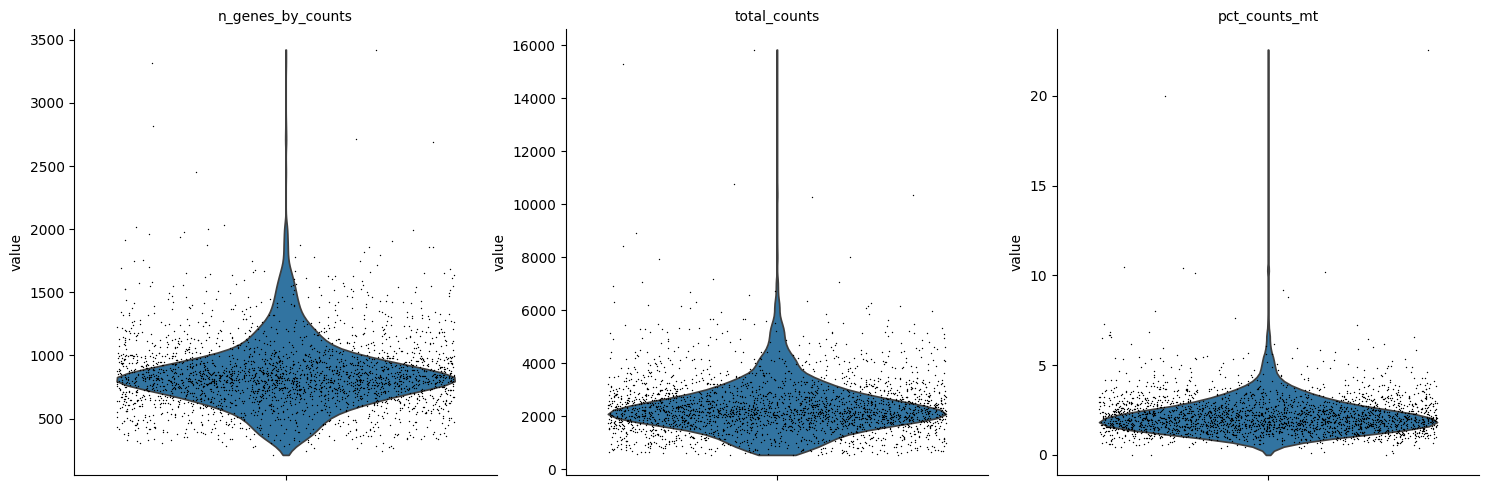

In [5]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

In [6]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.pct_counts_mt < 20, :]
print("Cells remaining after QC:", adata.n_obs)

Cells remaining after QC: 2698


In [7]:
print("Genes remaining:", adata.n_vars)

Genes remaining: 13714


### QC Results
After filtering, 2,698 cells and 13,714 genes remained (removed 2 cells and 19,024 genes). The low cell removal rate (0.07%) indicates high sample quality — consistent with the clean violin plots showing MT% below 5% for most cells.

C:\Users\hp\anaconda3\envs\scrna\lib\site-packages\scanpy\preprocessing\_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


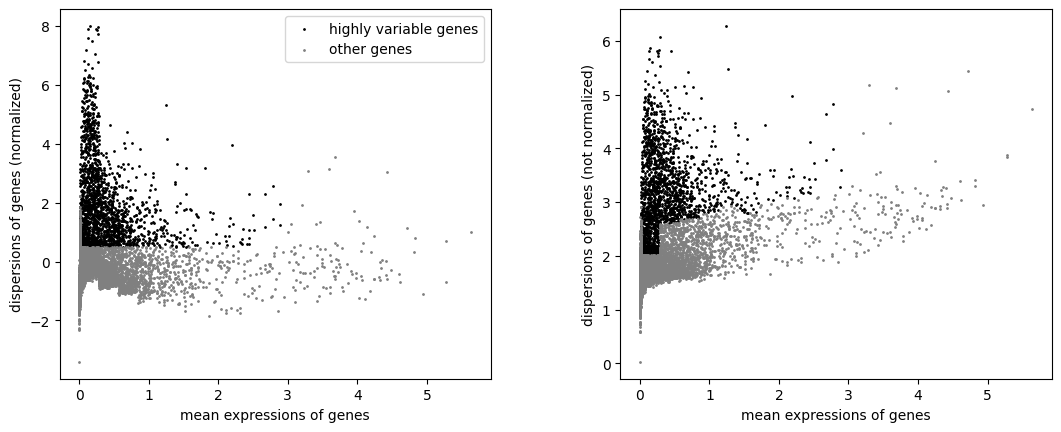

HVGs selected: 1865


In [8]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)
adata.raw = adata
adata = adata[:, adata.var.highly_variable]
print("HVGs selected:", adata.n_vars)

C:\Users\hp\anaconda3\envs\scrna\lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
C:\Users\hp\anaconda3\envs\scrna\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


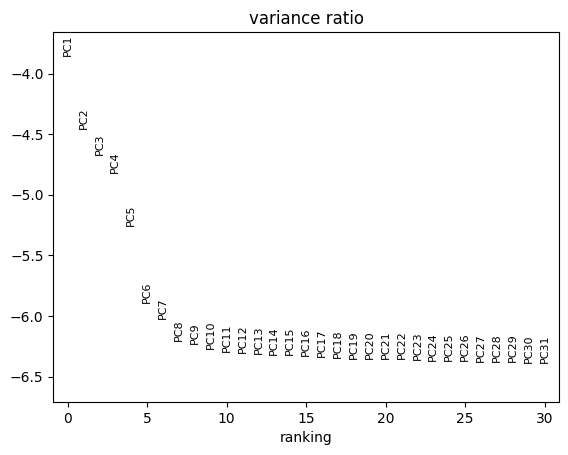

C:\Users\hp\anaconda3\envs\scrna\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\hp\AppData\Local\Temp\ipykernel_7720\2797227937.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


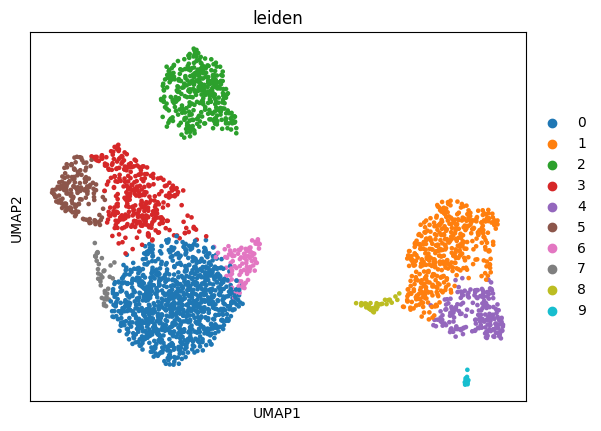

In [9]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)
sc.tl.leiden(adata, resolution=0.5)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['leiden'])

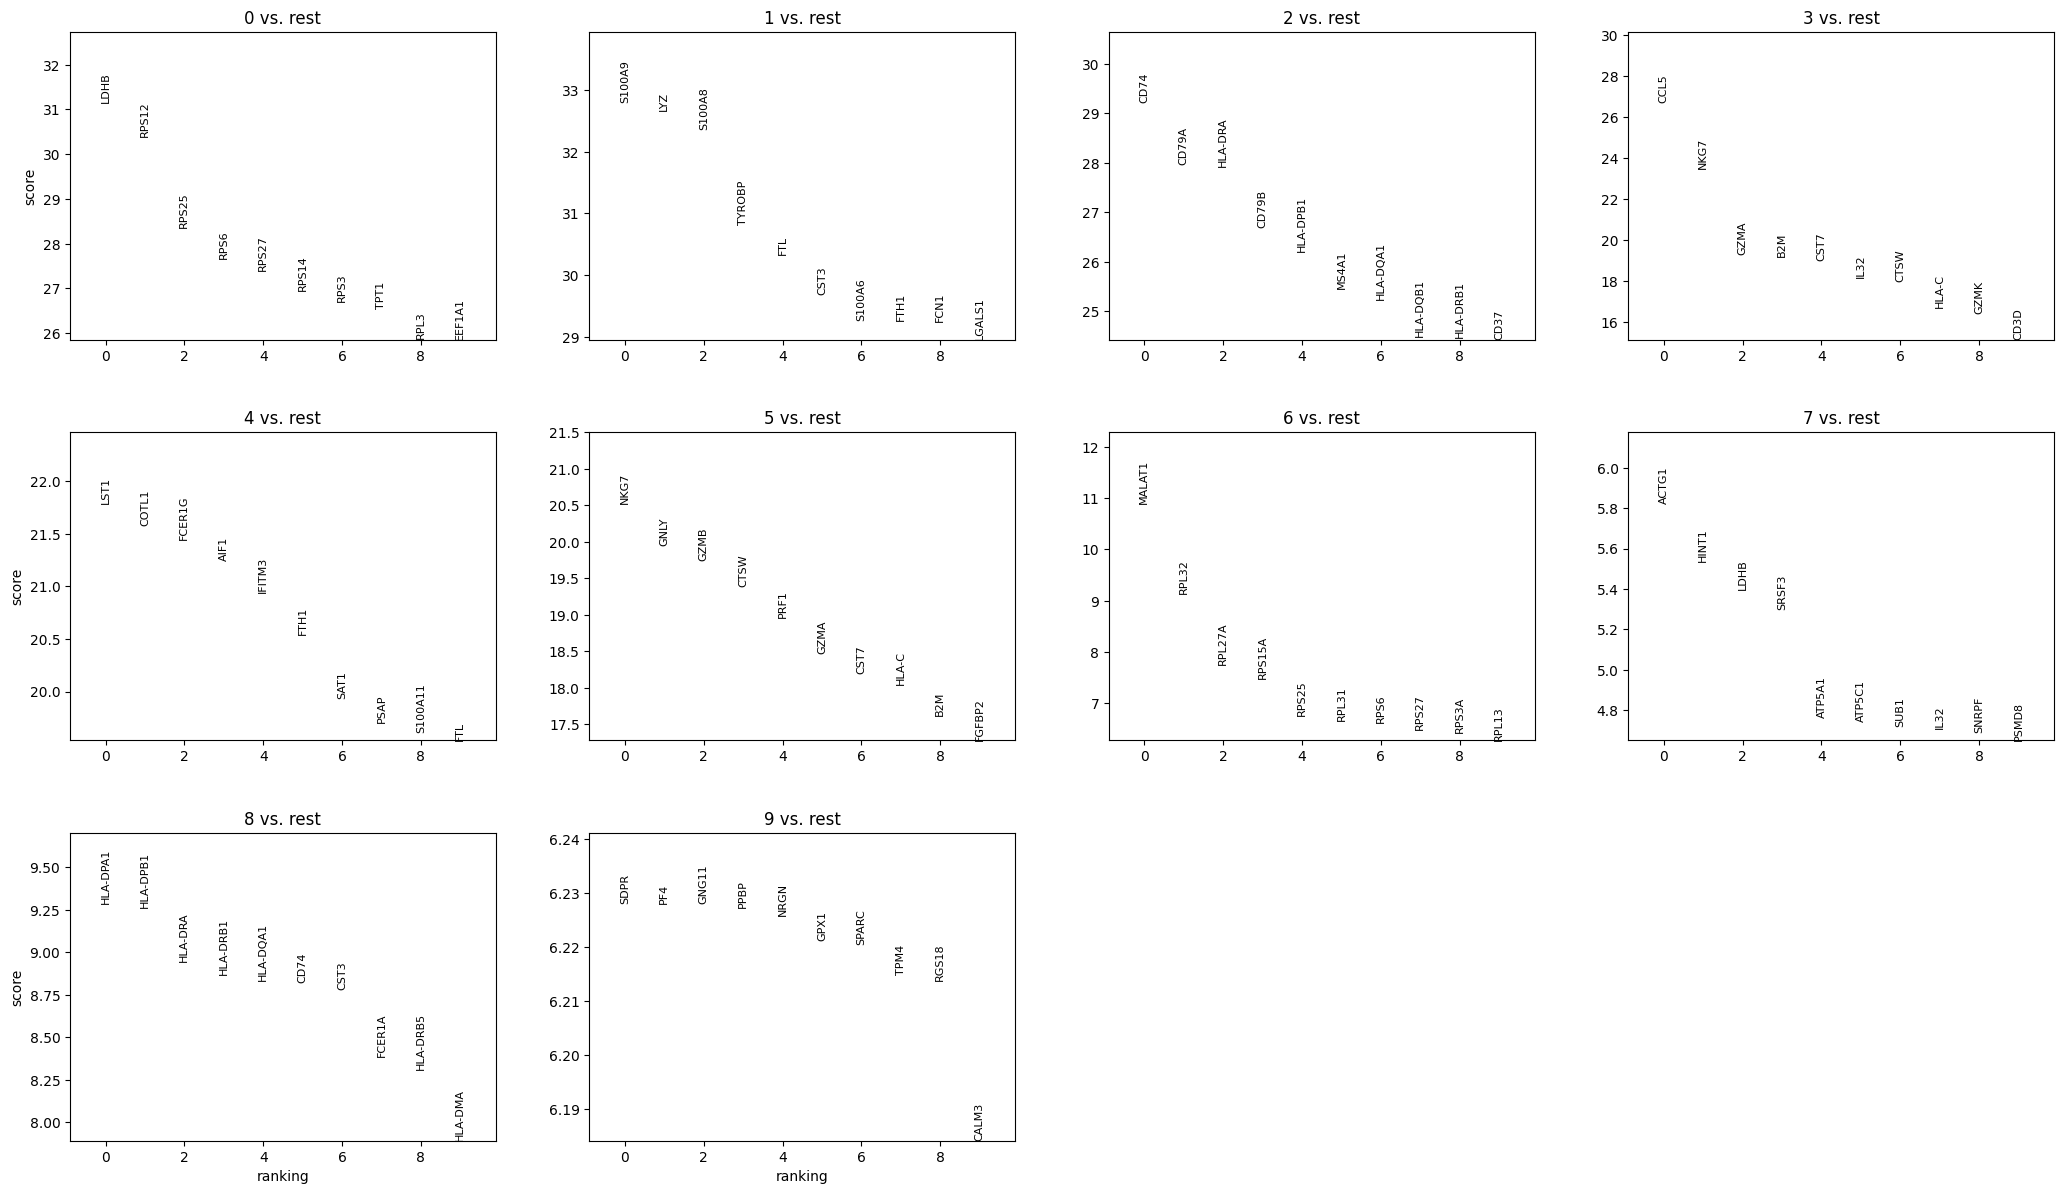

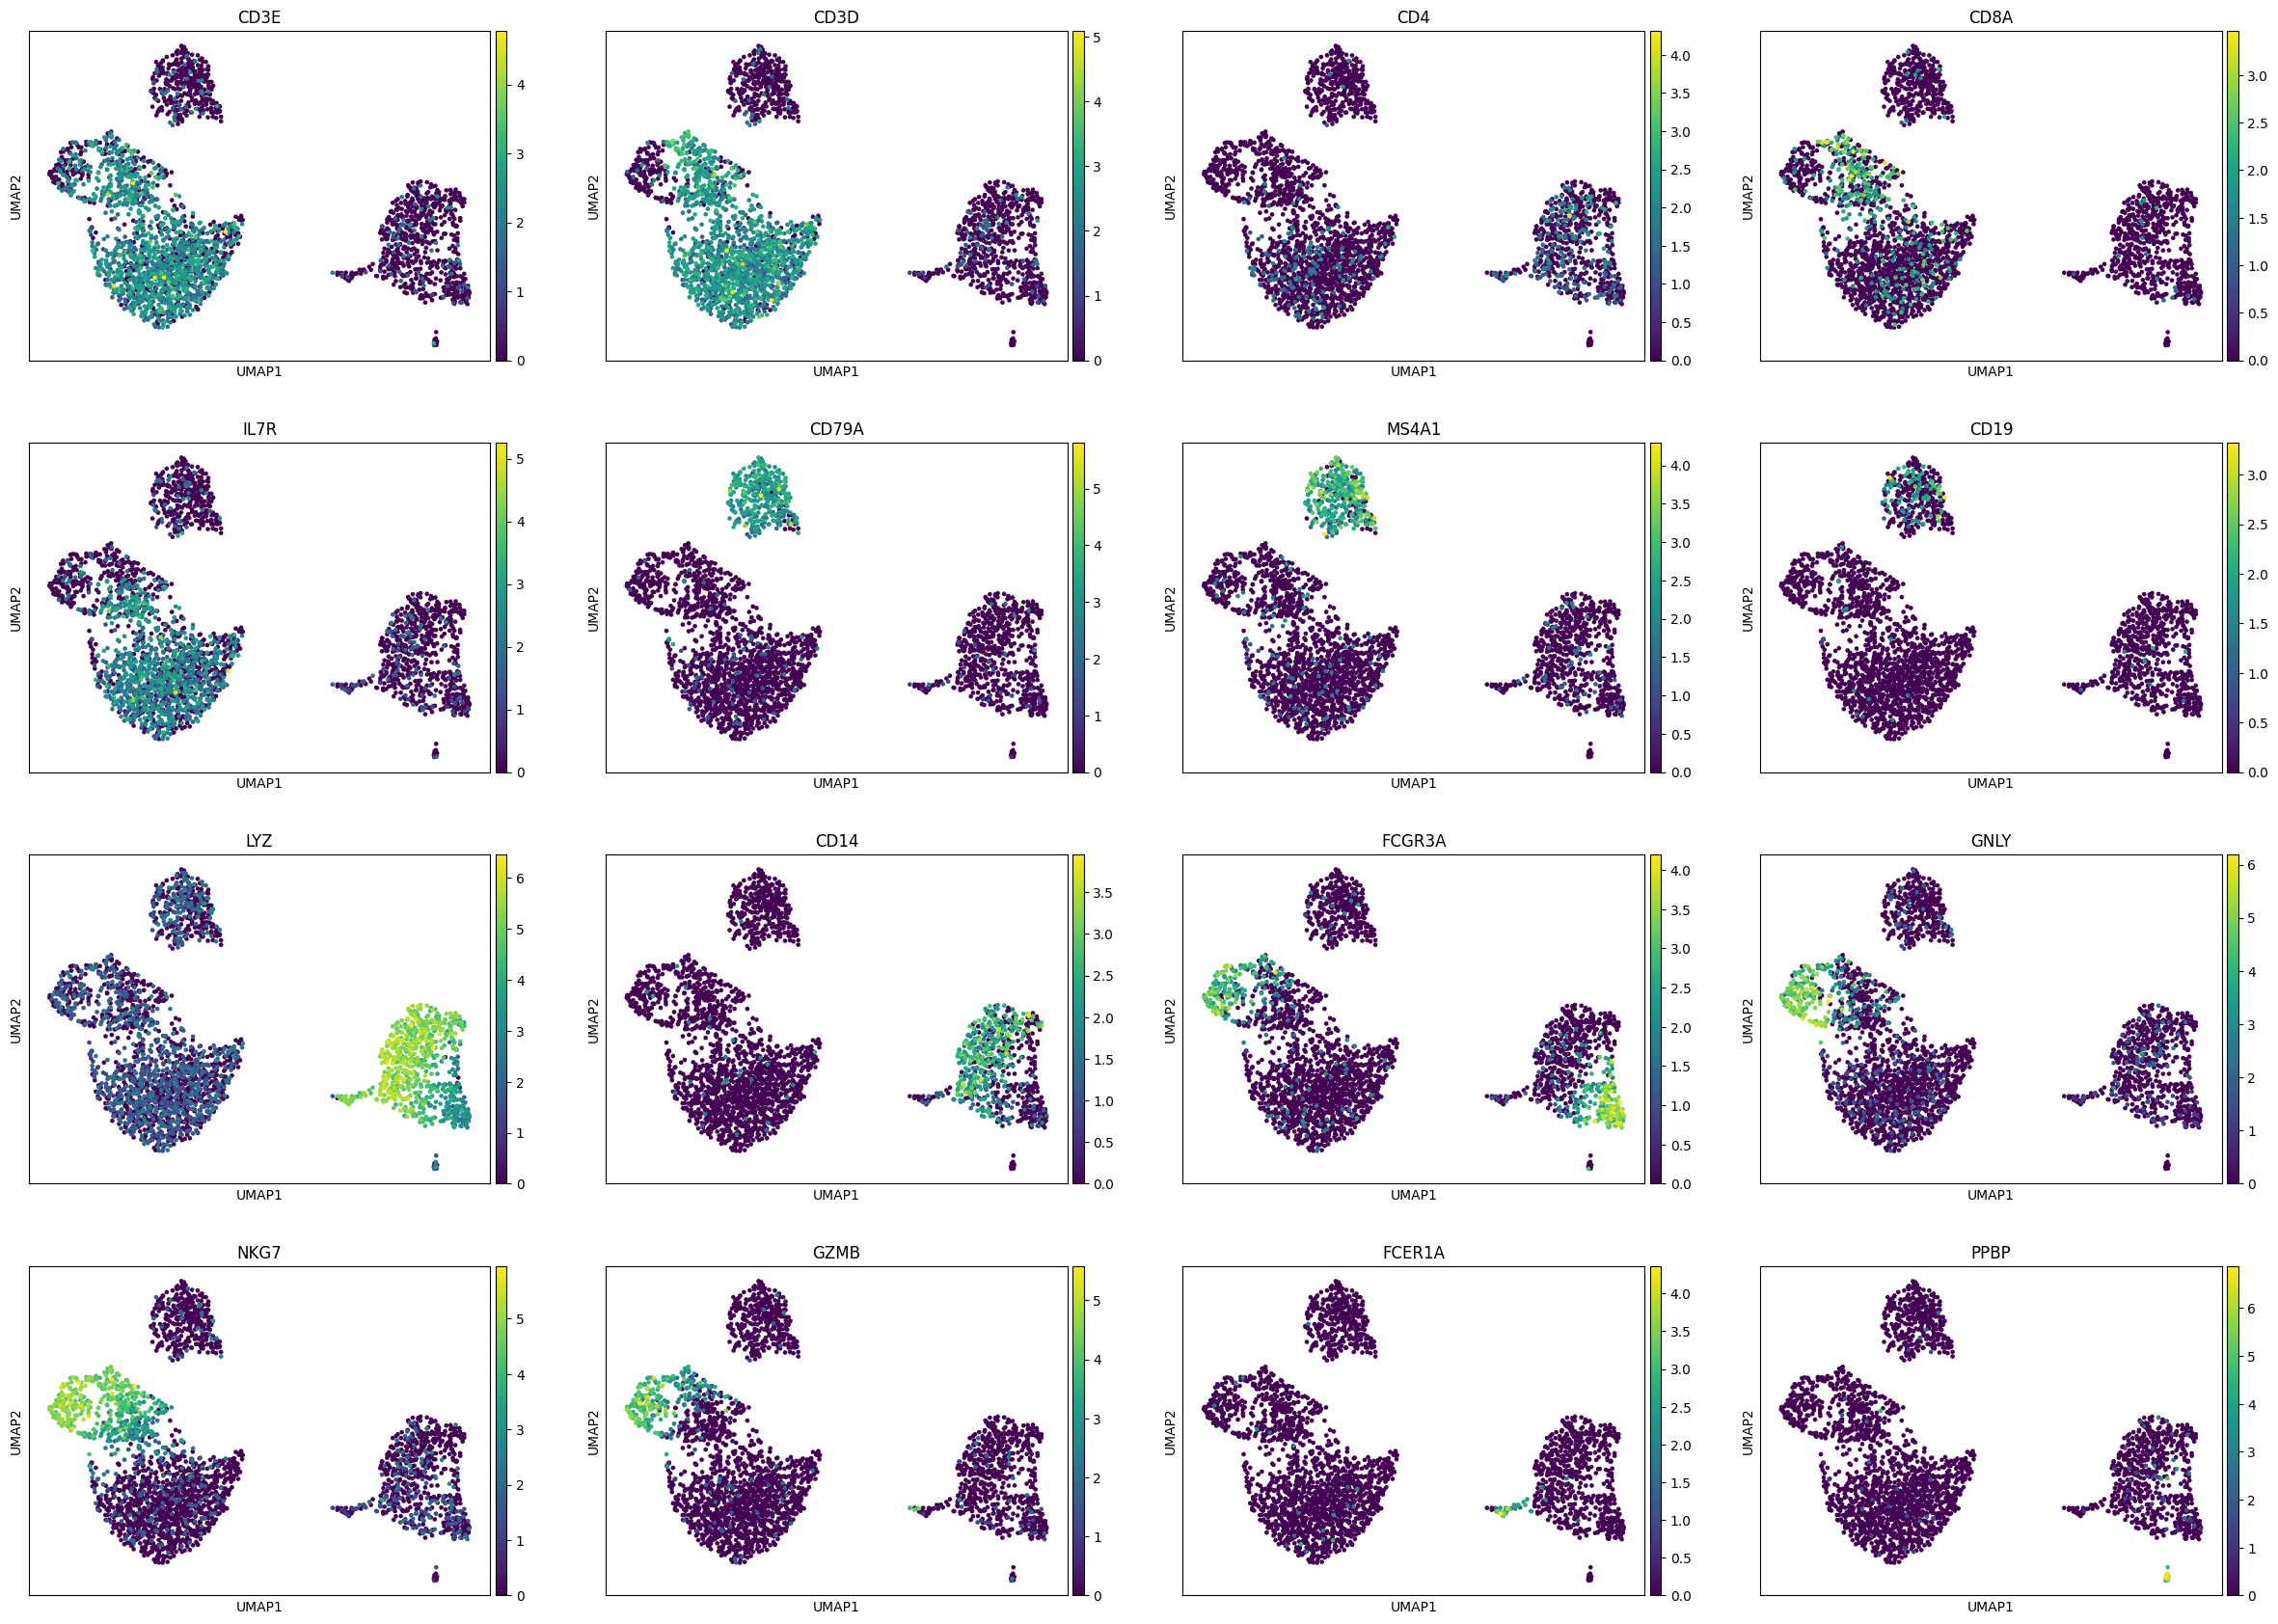

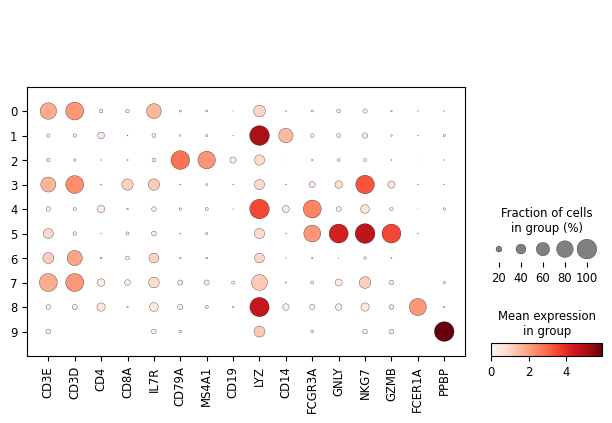

In [10]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

marker_genes = ['CD3E', 'CD3D', 'CD4', 'CD8A', 'IL7R',
                'CD79A', 'MS4A1', 'CD19',
                'LYZ', 'CD14', 'FCGR3A',
                'GNLY', 'NKG7', 'GZMB',
                'FCER1A', 'PPBP']

sc.pl.umap(adata, color=marker_genes, ncols=4)
sc.pl.dotplot(adata, marker_genes, groupby='leiden')

## Biological Findings
Analysis identified 10 distinct immune cell populations in human peripheral blood. The UMAP shows a clear separation between the lymphoid lineage (T cells, B cells, NK cells — left cluster) and myeloid lineage (monocytes — right cluster), reflecting the two major branches of the immune system.
T cells formed the largest population with both naive and memory CD4+ subtypes detected, consistent with a healthy adult donor. A rare platelet population (cluster 9) was also identified, likely representing contamination during blood processing.

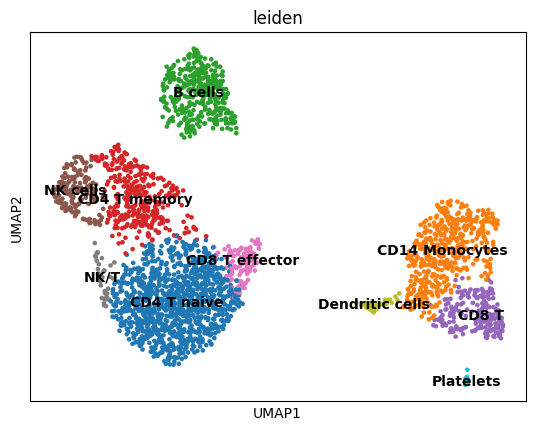

In [11]:
new_cluster_names = ['CD4 T naive', 'CD14 Monocytes', 'B cells', 'CD4 T memory',
                     'CD8 T', 'NK cells', 'CD8 T effector', 'NK/T',
                     'Dendritic cells', 'Platelets']

adata.rename_categories('leiden', new_cluster_names)
sc.pl.umap(adata, color='leiden', legend_loc='on data')

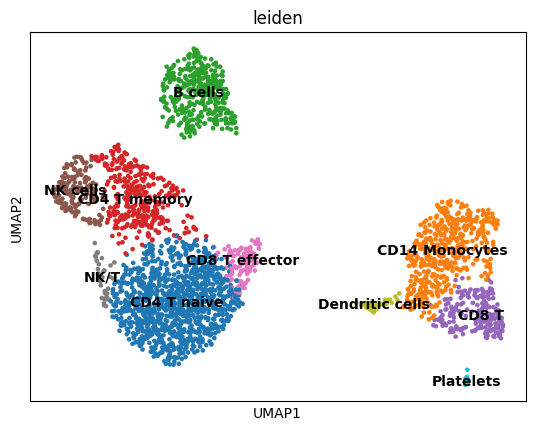

In [12]:
# save your final UMAP — the most important figure
sc.pl.umap(adata, color='leiden', legend_loc='on data',
           save='_annotated_final.png')

In [13]:
import matplotlib.pyplot as plt

# after any sc.pl plot, immediately run:
plt.savefig('figures/umap_annotated.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/umap_annotated.pdf', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [14]:
import os
os.makedirs('figures', exist_ok=True)

In [15]:
adata.write('pbmc3k_analyzed.h5ad')